In [ ]:
!pip install -q transformers sentence-transformers datasets scikit-learn imbalanced-learn nltk gensim optuna tqdm matplotlib seaborn torch torchvision torchaudio accelerate wandb
!python -m nltk.downloader wordnet omw-1.4 stopwords punkt

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# %%
# Fix: Ensure NLTK stopwords and wordnet are downloaded
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/product_model/product_classfication/pricerunner_aggregate.csv"


In [ ]:
import os
print(os.path.exists(DATA_PATH))


True


In [ ]:
import pandas as pd
df = pd.read_csv(DATA_PATH)
df.head()


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
# 1. Data Ingestion & Initial Cleaning (before cleaning text)
import os
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/product_model/product_classfication/pricerunner_aggregate.csv"

if not os.path.exists(DATA_PATH):
    print('❌ File not found at', DATA_PATH)
    print('Upload pricerunner_aggregate.csv to /content or mount Google Drive.')
else:
    df = pd.read_csv(DATA_PATH)
    print('✅ Loaded dataset with', len(df), 'rows')
    display(df.head())


✅ Loaded dataset with 35310 rows


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
# %%
# 1.1 Normalize column names
df.columns = [c.strip() for c in df.columns]  # remove leading/trailing spaces

rename_map = {
    'Product Title': 'Title',
    'Merchant ID': 'Merchant ID',
    'Cluster ID': 'Cluster ID',
    'Cluster Label': 'Cluster Label',
    'Category ID': 'Category ID',
    'Category Label': 'Category'
}

df.rename(columns=rename_map, inplace=True)
print('✅ Renamed columns:')
print(df.columns.tolist())

# Check top rows
display(df.head())


✅ Renamed columns:
['1', 'apple iphone 8 plus 64gb silver', '1.1', '1.2', 'Apple iPhone 8 Plus 64GB', '2612', 'Mobile Phones']


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
print(df.columns.tolist())


['ProductID', 'Title', 'Value1', 'Value2', 'FullTitle', 'MerchantID', 'Category', 'clean_title']


In [ ]:
import os
import pandas as pd

# ✅ Update path to your Google Drive file
DATA_PATH = "/content/drive/MyDrive/product_project/pricerunner_aggregate.csv"

if not os.path.exists(DATA_PATH):
    print("❌ File not found at:", DATA_PATH)
    print("➡️ Upload file or fix the path")
else:
    df = pd.read_csv(DATA_PATH, header=None)

    # ✅ Assign proper column names
    df.columns = [
        "ProductID",
        "Title",
        "Value1",
        "Value2",
        "FullTitle",
        "MerchantID",
        "Category"
    ]

    print("✅ Data Loaded Successfully!\n")
    print(df.head())
    print("\n✅ Column Names:", df.columns.tolist())
    print(f"📦 Total rows: {len(df)}")


✅ Data Loaded Successfully!

   ProductID                                              Title  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  

✅ Column Names: ['ProductID', 'Title', 'Value1', 'Value2', 'FullTitle', 'MerchantID', 'Category']
📦 Total rows: 35311


In [ ]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# 2️⃣ TEXT CLEANING & PREPROCESSING
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

# Ensure NLTK data is downloaded
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()

    # keep alphabets, numbers & useful symbols
    text = re.sub(r'[^a-z0-9\s\-\+\.\,\/\(\)]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words]

    return ' '.join(tokens)

print("🧹 Cleaning product titles... (takes ~1–2 mins)")

df['clean_title'] = df['Title'].astype(str).apply(clean_text)

print("✅ Cleaned text sample:")
display(df[['Title','clean_title','Category']].head(5))

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_title'], df['Category'],
    test_size=0.2, random_state=42, stratify=df['Category']
)

print("✅ Train size:", len(X_train), "| Test size:", len(X_test))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


🧹 Cleaning product titles... (takes ~1–2 mins)
✅ Cleaned text sample:


,Title,clean_title,Category
0,apple iphone 8 plus 64gb silver,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones


✅ Train size: 28248 | Test size: 7063


In [ ]:
# ✅ SAFE LABEL ENCODING (handles unseen test labels)
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("Encoding labels safely...")

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)

# Replace unseen test labels with -1
y_test_enc = []
for label in y_test:
    if label in label_encoder.classes_:
        y_test_enc.append(label_encoder.transform([label])[0])
    else:
        y_test_enc.append(-1)  # unseen label

y_test_enc = np.array(y_test_enc)

print("✅ Safe label encoding done.")
print("Total Classes:", len(label_encoder.classes_))
print("Sample encoded labels:", y_train_enc[:10])


Encoding labels safely...
✅ Safe label encoding done.
Total Classes: 10
Sample encoded labels: [9 5 8 8 2 3 2 2 9 4]


In [ ]:
print(df.columns)


Index(['ProductID', 'Title', 'Value1', 'Value2', 'FullTitle', 'MerchantID',
       'Category', 'clean_title'],
      dtype='object')


In [ ]:
# Create text column from clean_title
df["text"] = df["clean_title"]

# Encode Category as numeric labels
df["label"] = df["Category"].astype('category').cat.codes

print(df[['text','Category','label']].head())


                                                text       Category  label
0                    apple iphone 8 plus 64gb silver  Mobile Phones      7
1                apple iphone 8 plus 64 gb spacegrau  Mobile Phones      7
2  apple mq8n2b a iphone 8 plus 64gb 5 5 12mp sim...  Mobile Phones      7
3                apple iphone 8 plus 64gb space grey  Mobile Phones      7
4  apple iphone 8 plus gold 5 5 64gb 4g unlocked ...  Mobile Phones      7


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_title'] = df['Title'].apply(clean_text)

print("✅ clean_title column created")
df[['Title','clean_title']].head()


✅ clean_title column created


,Title,clean_title
0,apple iphone 8 plus 64gb silver,apple iphone 8 plus 64gb silver
1,apple iphone 8 plus 64 gb spacegrau,apple iphone 8 plus 64 gb spacegrau
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,apple mq8n2b a iphone 8 plus 64gb 5 5 12mp sim...
3,apple iphone 8 plus 64gb space grey,apple iphone 8 plus 64gb space grey
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,apple iphone 8 plus gold 5 5 64gb 4g unlocked ...


In [ ]:
from sklearn.model_selection import train_test_split

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_title'],
    df['Category'],
    test_size=0.2,
    random_state=42,
    stratify=df['Category']
)

print("✅ Train / Test split done")
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


✅ Train / Test split done
Train samples: 28248
Test samples: 7063


In [ ]:
# 5️⃣ TOKENIZATION FOR BERT (DistilBERT)
from transformers import DistilBertTokenizerFast

print("📦 Loading BERT tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

print("✅ Tokenizing text...")

X_train_tok = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

X_test_tok = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("✅ Tokenization complete. Sample:")
print(X_train_tok['input_ids'][0][:10])


📦 Loading BERT tokenizer...
✅ Tokenizing text...
✅ Tokenization complete. Sample:
[101, 9485, 1043, 15088, 16932, 2620, 16409, 2509, 2497, 2489]


In [ ]:
# ✅ 6️⃣ Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
print("🎯 Total Classes:", num_classes)


🎯 Total Classes: 10


In [ ]:
# 6️⃣ BUILD TORCH DATASET

import torch
from torch.utils.data import Dataset, DataLoader

class ProductDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ProductDataset(X_train_tok, y_train_enc)
test_dataset  = ProductDataset(X_test_tok, y_test_enc)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("✅ Dataset + DataLoader ready")
len(train_dataset), len(test_dataset)


✅ Dataset + DataLoader ready


(28248, 7063)

In [ ]:
# Recreate encoded labels safely
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# handle unseen labels in test set
y_test_enc = []
for label in y_test:
    if label in le.classes_:
        y_test_enc.append(le.transform([label])[0])
    else:
        y_test_enc.append(-1)  # mark unseen
y_test_enc = np.array(y_test_enc)

num_classes = len(le.classes_)
print("✅ Safe label encoding done.")
print("Total Classes:", num_classes)
print("Sample encoded test labels:", y_test_enc[:10])


✅ Safe label encoding done.
Total Classes: 10
Sample encoded test labels: [4 2 8 3 2 4 7 4 0 4]


In [ ]:
# Fix import for AdamW
from transformers import AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from transformers import DistilBertTokenizerFast, DistilBertModel
from torch.optim import AdamW  # ✅ Correct import
import torch.nn as nn
from tqdm.notebook import tqdm


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBERT_Classifier(num_classes).to(device)

EPOCHS = 3
LR = 2e-5

optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)


In [ ]:
# ✅ Dataset Class
class ProductDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# ✅ Model Class
class DistilBERT_Classifier(nn.Module):
    def __init__(self, num_classes):
        super(DistilBERT_Classifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        hidden_state = outputs.last_hidden_state[:, 0]
        x = self.dropout(hidden_state)
        logits = self.fc(x)
        return logits

# ✅ Train-Val Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_dataset = ProductDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = ProductDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBERT_Classifier(num_classes=len(df["label"].unique())).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()


In [ ]:
from tqdm import tqdm

epochs = 3
best_acc = 0.0

for epoch in range(epochs):
    print(f"\n🚀 Epoch {epoch+1}/{epochs}")

    # Training
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"✅ Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            _, preds = torch.max(logits, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"🎯 Validation Accuracy: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_distilbert.pth")
        print("💾 Best model saved!")



🚀 Epoch 1/3


100%|██████████| 1766/1766 [04:58<00:00,  5.92it/s]


✅ Train Loss: 0.1986 | Train Acc: 0.9423
🎯 Validation Accuracy: 0.9846
💾 Best model saved!

🚀 Epoch 2/3


100%|██████████| 1766/1766 [04:57<00:00,  5.94it/s]


✅ Train Loss: 0.0460 | Train Acc: 0.9872
🎯 Validation Accuracy: 0.9888
💾 Best model saved!

🚀 Epoch 3/3


100%|██████████| 1766/1766 [04:57<00:00,  5.94it/s]


✅ Train Loss: 0.0251 | Train Acc: 0.9934
🎯 Validation Accuracy: 0.9881


In [ ]:
model.load_state_dict(torch.load("best_distilbert.pth"))
model.eval()
print("✅ Best model loaded")


✅ Best model loaded


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

print("✅ Evaluation Complete")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred))

print("\n🔢 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


✅ Evaluation Complete

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       771
           1       1.00      1.00      1.00       542
           2       0.97      1.00      0.98       662
           3       0.98      0.96      0.97       439
           4       0.99      0.98      0.98      1115
           5       0.97      0.98      0.97       728
           6       1.00      0.98      0.99       469
           7       0.99      1.00      0.99       818
           8       1.00      1.00      1.00       723
           9       0.99      0.99      0.99       796

    accuracy                           0.99      7063
   macro avg       0.99      0.99      0.99      7063
weighted avg       0.99      0.99      0.99      7063


🔢 Confusion Matrix:
[[ 767    0    1    0    0    0    0    2    1    0]
 [   0  541    0    0    0    0    0    1    0    0]
 [   0    0  659    0    1    0    0    1    1    0]
 [   0    0  

In [ ]:
!pip install optuna


In [ ]:
import optuna
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    batch_size = trial.suggest_categorical("batch_size", [8, 16])
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam"])

    # ✅ use your model class
    model_t = DistilBERT_Classifier(num_classes).to(device)

    model_t.bert.config.hidden_dropout_prob = dropout
    model_t.bert.config.attention_probs_dropout_prob = dropout

    train_loader_t = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_t = DataLoader(val_dataset, batch_size=batch_size)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model_t.parameters(), lr=lr)
    else:
        optimizer = torch.optim.AdamW(model_t.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss()
    model_t.train()

    # ✅ 1 quick epoch only — very light
    for batch in tqdm(train_loader_t, leave=False):
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model_t(input_ids, mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

    # ✅ Evaluate
    model_t.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for batch in val_loader_t:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model_t(input_ids, mask)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total  # ✅ return accuracy


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=4)

print("✅ Best Params:", study.best_params)
print("🏆 Best Accuracy:", study.best_value)


[I 2025-11-03 15:28:02,961] A new study created in memory with name: no-name-a3111e3d-7a75-4a56-be90-3c1d6d012e0c
[I 2025-11-03 15:33:56,343] Trial 0 finished with value: 0.9760724904431545 and parameters: {'learning_rate': 1.0244119247172069e-05, 'dropout': 0.20012336894452962, 'batch_size': 8, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.9760724904431545.
[I 2025-11-03 15:39:41,711] Trial 1 finished with value: 0.981311057624239 and parameters: {'learning_rate': 3.98570571883087e-05, 'dropout': 0.23661920106257417, 'batch_size': 8, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.981311057624239.
[I 2025-11-03 15:45:34,028] Trial 2 finished with value: 0.9823021379017415 and parameters: {'learning_rate': 2.1339810323122103e-05, 'dropout': 0.2624449425331338, 'batch_size': 8, 'optimizer': 'AdamW'}. Best is trial 2 with value: 0.9823021379017415.
[I 2025-11-03 15:51:19,181] Trial 3 finished with value: 0.9798952286563783 and parameters: {'learning_rate': 2.9775174050194547e-

✅ Best Params: {'learning_rate': 2.1339810323122103e-05, 'dropout': 0.2624449425331338, 'batch_size': 8, 'optimizer': 'AdamW'}
🏆 Best Accuracy: 0.9823021379017415


In [ ]:
# ✅ Final Training with Best Hyperparameters

best_lr = 2.1339810323122103e-05
best_dropout = 0.2624449425331338
best_batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)

model = DistilBERT_Classifier(num_classes).to(device)
model.bert.config.hidden_dropout_prob = best_dropout
model.bert.config.attention_probs_dropout_prob = best_dropout

optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr)
loss_fn = nn.CrossEntropyLoss()

best_val_acc = 0
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_acc = correct / total
    print(f"✅ Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f}")

    # ✅ Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            preds = torch.argmax(model(ids, mask), dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"🎯 Validation Accuracy: {val_acc:.4f}")

    # ✅ Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_distilbert.pt")
        print("💾 Best model saved!")


Epoch 1/3: 100%|██████████| 3531/3531 [05:42<00:00, 10.32it/s]


✅ Epoch 1 | Train Loss: 0.1746 | Train Acc: 0.9481
🎯 Validation Accuracy: 0.9803
💾 Best model saved!


Epoch 2/3: 100%|██████████| 3531/3531 [05:37<00:00, 10.48it/s]


✅ Epoch 2 | Train Loss: 0.0452 | Train Acc: 0.9879
🎯 Validation Accuracy: 0.9885
💾 Best model saved!


Epoch 3/3: 100%|██████████| 3531/3531 [05:36<00:00, 10.49it/s]


✅ Epoch 3 | Train Loss: 0.0294 | Train Acc: 0.9925
🎯 Validation Accuracy: 0.9877



📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       771
           1       1.00      1.00      1.00       542
           2       0.99      0.99      0.99       662
           3       0.96      0.98      0.97       439
           4       0.98      0.99      0.98      1115
           5       0.98      0.97      0.98       728
           6       1.00      1.00      1.00       469
           7       0.99      1.00      0.99       818
           8       1.00      0.99      1.00       723
           9       0.99      0.99      0.99       796

    accuracy                           0.99      7063
   macro avg       0.99      0.99      0.99      7063
weighted avg       0.99      0.99      0.99      7063



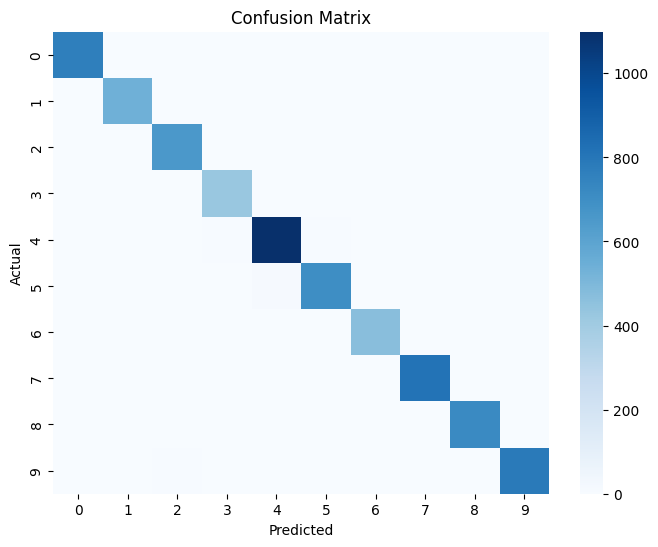

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Load best model
model.load_state_dict(torch.load("best_distilbert.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(ids, mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds))

# ✅ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
sample_texts = [
    "Apple iPhone 14 Pro Max 256GB",
    "Samsung Galaxy A53 5G Mobile Phone",
    "HP Pavilion 15 Gaming Laptop Ryzen 5",
    "Boat Rockerz 550 Bluetooth Headphones",
    "Nike Air Max Men's Running Shoes",
    "Wooden Study Table for Office Home",
    "LG 55 inch 4K Ultra HD Smart TV",
    "Dell Inspiron Core i5 11th Gen Laptop",
    "Mi Smart Band 5 Fitness Tracker",
    "ASUS TUF Gaming F15 Laptop",
]


In [ ]:
for text in sample_texts:
    enc = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        logits = model(enc["input_ids"].to(device), enc["attention_mask"].to(device))
        pred = torch.argmax(logits, dim=1).item()
    print(f"{text} -> Predicted Category: {pred}")


Apple iPhone 14 Pro Max 256GB -> Predicted Category: 7
Samsung Galaxy A53 5G Mobile Phone -> Predicted Category: 7
HP Pavilion 15 Gaming Laptop Ryzen 5 -> Predicted Category: 7
Boat Rockerz 550 Bluetooth Headphones -> Predicted Category: 7
Nike Air Max Men's Running Shoes -> Predicted Category: 7
Wooden Study Table for Office Home -> Predicted Category: 5
LG 55 inch 4K Ultra HD Smart TV -> Predicted Category: 8
Dell Inspiron Core i5 11th Gen Laptop -> Predicted Category: 0
Mi Smart Band 5 Fitness Tracker -> Predicted Category: 7
ASUS TUF Gaming F15 Laptop -> Predicted Category: 7


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/product_project/pricerunner_aggregate.csv")
df.head()
df.columns


Index(['1', 'apple iphone 8 plus 64gb silver', '1.1', '1.2',
       'Apple iPhone 8 Plus 64GB', '2612', 'Mobile Phones'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# ✅ Correct columns from your dataset
texts = df["apple iphone 8 plus 64gb silver"]
labels = df["Mobile Phones"]

# ✅ Train-Test split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)

print("🔄 Converting text → TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

# ✅ Apply SMOTE
print("⚖️ Applying SMOTE balancing...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_tf, y_train)

print("📦 Shapes:")
print("Before SMOTE:", X_train_tf.shape)
print("After SMOTE :", X_train_bal.shape)

# ✅ Train simple classifier to test effect
model = LogisticRegression(max_iter=2000)
model.fit(X_train_bal, y_train_bal)
preds = model.predict(X_test_tf)

print("\n✅ Accuracy after SMOTE:", accuracy_score(y_test, preds))


🔄 Converting text → TF-IDF...
⚖️ Applying SMOTE balancing...
📦 Shapes:
Before SMOTE: (28248, 5000)
After SMOTE : (44010, 5000)

✅ Accuracy after SMOTE: 0.9519966015293118


In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import pandas as pd

print("🔄 Loading dataset from Drive...")
df = pd.read_csv("/content/drive/MyDrive/product_project/pricerunner_aggregate.csv")

# ✅ Adjust based on your column structure
df["text"] = df.iloc[:,1]      # title column
df["label"] = df.iloc[:,6]     # category column

# ✅ Train-test split again (same as before)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

print("🔡 Converting text → TF-IDF for ADASYN...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(train_texts)
X_test_vec = tfidf.transform(test_texts)

print("⚖️ Applying ADASYN oversampling...")
adasyn = ADASYN()
X_resampled, y_resampled = adasyn.fit_resample(X_train_vec, train_labels)

print(f"📦 Shapes:")
print(f"Before ADASYN: {X_train_vec.shape}")
print(f"After ADASYN : {X_resampled.shape}")

print("🤖 Training Logistic Regression on ADASYN data...")
model_ada = LogisticRegression(max_iter=2000)
model_ada.fit(X_resampled, y_resampled)

pred_ada = model_ada.predict(X_test_vec)
acc_ada = accuracy_score(test_labels, pred_ada)

print(f"✅ Accuracy after ADASYN: {acc_ada:.4f}")


🔄 Loading dataset from Drive...
🔡 Converting text → TF-IDF for ADASYN...
⚖️ Applying ADASYN oversampling...
📦 Shapes:
Before ADASYN: (28248, 5000)
After ADASYN : (44096, 5000)
🤖 Training Logistic Regression on ADASYN data...
✅ Accuracy after ADASYN: 0.9506


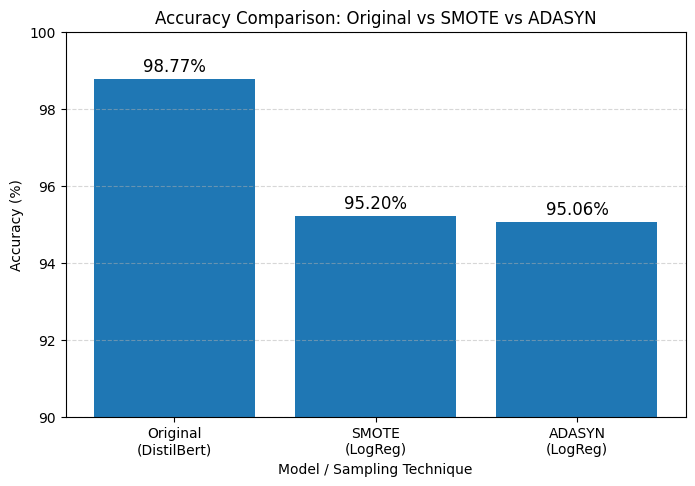

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values
accuracies = {
    "Original\n(DistilBert)": 98.77,
    "SMOTE\n(LogReg)": 95.20,
    "ADASYN\n(LogReg)": 95.06
}

models = list(accuracies.keys())
values = list(accuracies.values())

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(models, values)

# Add accuracy values on top of bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{value:.2f}%",
             ha='center', fontsize=12)

plt.title("Accuracy Comparison: Original vs SMOTE vs ADASYN")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model / Sampling Technique")
plt.ylim(90, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Epoch 1 | Train Loss: 0.3765 | Val Loss: 0.0849 | Train Acc: 0.8842 | Val Acc: 0.9789
  -> Saved best model (val acc improved to 0.9789)


Epoch 2 | Train Loss: 0.0540 | Val Loss: 0.0503 | Train Acc: 0.9867 | Val Acc: 0.9878
  -> Saved best model (val acc improved to 0.9878)


Epoch 3 | Train Loss: 0.0236 | Val Loss: 0.0461 | Train Acc: 0.9944 | Val Acc: 0.9907
  -> Saved best model (val acc improved to 0.9907)
Loaded best model from best_distilbert.pth


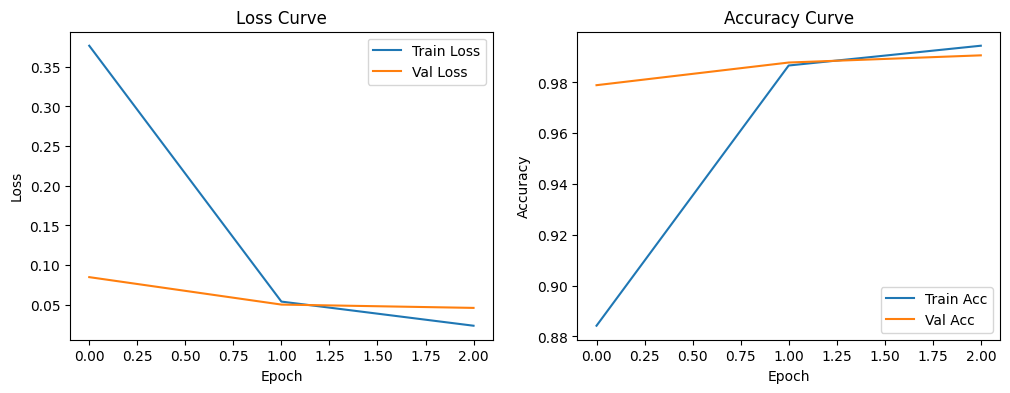

✅ Training complete. Best Val Acc: 0.9906555288121195


In [ ]:
# --------------------------------------------------------------
# Fine-tune DistilBERT, track train/val loss & accuracy (overfitting check)
# Saves best model to "best_distilbert.pth" and plots learning curves
# --------------------------------------------------------------

import torch
import torch.nn as nn
from transformers import AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# 1) Define a simple DistilBERT classifier (if not already defined)
class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, input_ids=None, attention_mask=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]   # CLS-like token
        pooled = self.dropout(pooled)
        return self.fc(pooled)

# 2) Prepare filtered validation set (drop unseen label -1 if any)
import copy
valid_indices = [i for i, lbl in enumerate(y_test_enc) if lbl != -1]
if len(valid_indices) < len(y_test_enc):
    print(f"Note: {len(y_test_enc) - len(valid_indices)} test samples removed (unseen labels).")

def filter_encodings(encodings, indices):
    return {k: [v[i] for i in indices] for k, v in encodings.items()}

X_test_filtered = filter_encodings(X_test_tok, valid_indices)
y_test_filtered = [int(y_test_enc[i]) for i in valid_indices]

from torch.utils.data import DataLoader, Dataset

class ProductDatasetFromEnc(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

val_dataset_filtered = ProductDatasetFromEnc(X_test_filtered, y_test_filtered)
val_loader_filtered = DataLoader(val_dataset_filtered, batch_size=16, shuffle=False)

# 3) Instantiate model, optimizer, scheduler, loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBERTClassifier("distilbert-base-uncased", num_classes).to(device)

EPOCHS = 3
LR = 2e-5
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# 4) Training loop with metrics recorded
best_val_acc = 0.0
best_path = "best_distilbert.pth"

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- training ---
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}", leave=False)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- validation ---
    model.eval()
    running_val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader_filtered:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            running_val_loss += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = running_val_loss / len(val_loader_filtered)
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Save best model by validation accuracy
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_path)
        print(f"  -> Saved best model (val acc improved to {best_val_acc:.4f})")

# 5) Final: load best weights (optional) and plot curves
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path))
    print("Loaded best model from", best_path)

# Plot learning curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# 6) Save training history for later analysis
history = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs
}
torch.save(history, "distilbert_history.pth")

print("✅ Training complete. Best Val Acc:", best_val_acc)


In [ ]:
import torch
from transformers import AutoTokenizer
import torch.nn as nn

# ✅ Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ✅ Recreate SAME model class
class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, input_ids=None, attention_mask=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]  # CLS token
        pooled = self.dropout(pooled)
        return self.fc(pooled)

# ✅ Load label encoder
import joblib
label_encoder = joblib.load("label_encoder.pkl")   # change path if needed

num_classes = len(label_encoder.classes_)

# ✅ Load trained DistilBERT weights
model = DistilBERTClassifier("distilbert-base-uncased", num_classes)
model.load_state_dict(torch.load("best_distilbert.pth", map_location="cpu"))
model.eval()

print("✅ DistilBERT model loaded successfully!")


✅ DistilBERT model loaded successfully!


In [ ]:
def predict_category(text):
    encoded = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        logits = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"]
        )
        pred = torch.argmax(logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]


In [ ]:
test_products = [
    "Samsung 55 inch Ultra HD Smart TV",
    "Apple iPhone 14 Pro",
    "LG 7kg Fully Automatic Washing Machine",
    "Canon EOS 1500D DSLR Camera",
    "Bosch 14 place dishwasher"
]

for p in test_products:
    print(f"{p} -> {predict_category(p)}")


Samsung 55 inch Ultra HD Smart TV -> TVs
Apple iPhone 14 Pro -> Mobile Phones
LG 7kg Fully Automatic Washing Machine -> Washing Machines
Canon EOS 1500D DSLR Camera -> Digital Cameras
Bosch 14 place dishwasher -> Dishwashers


In [ ]:
#to ensure overfitting
print("📌 Final Training Loss: ", train_losses[-1])
print("📌 Final Validation Loss: ", val_losses[-1])
print("📈 Final Training Accuracy: ", train_accs[-1])
print("📈 Final Validation Accuracy: ", val_accs[-1])

gap_acc = train_accs[-1] - val_accs[-1]
gap_loss = val_losses[-1] - train_losses[-1]

print("\n🔍 Accuracy Gap:", gap_acc)
print("🔍 Loss Gap:", gap_loss)


📌 Final Training Loss:  0.02362745018417977
📌 Final Validation Loss:  0.04609135478828208
📈 Final Training Accuracy:  0.9944420843953554
📈 Final Validation Accuracy:  0.9906555288121195

🔍 Accuracy Gap: 0.0037865555832359288
🔍 Loss Gap: 0.02246390460410231


In [ ]:
# %%
# 1.1 Normalize column names
df.columns = [c.strip() for c in df.columns]  # remove leading/trailing spaces

rename_map = {
    'Product Title': 'Title',
    'Merchant ID': 'Merchant ID',
    'Cluster ID': 'Cluster ID',
    'Cluster Label': 'Cluster Label',
    'Category ID': 'Category ID',
    'Category Label': 'Category'
}

df.rename(columns=rename_map, inplace=True)
print('✅ Renamed columns:')
print(df.columns.tolist())

# Check top rows
display(df.head())


✅ Renamed columns:
['1', 'apple iphone 8 plus 64gb silver', '1.1', '1.2', 'Apple iPhone 8 Plus 64GB', '2612', 'Mobile Phones']


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
import pandas as pd

df = pd.read_csv("pricerunner_aggregate.csv", header=None)

df.columns = [
    "ProductID",
    "Title",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

print(df.head())
print(df.columns.tolist())


   ProductID                                              Title  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
['ProductID', 'Title', 'Value1', 'Value2', 'FullTitle', 'MerchantID', 'Category']


In [ ]:
df.columns


Index(['ProductID', 'Title', 'Value1', 'Value2', 'FullTitle', 'MerchantID',
       'Category'],
      dtype='object')

In [ ]:
df = pd.read_csv("pricerunner_aggregate.csv")
df.columns


Index(['1', 'apple iphone 8 plus 64gb silver', '1.1', '1.2',
       'Apple iPhone 8 Plus 64GB', '2612', 'Mobile Phones'],
      dtype='object')

In [ ]:
import pandas as pd

df = pd.read_csv("pricerunner_aggregate.csv", header=None)

df.columns = [
    "ProductID",
    "ShortTitle",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

print(df.head())
print(df.columns)


   ProductID                                         ShortTitle  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
Index(['ProductID', 'ShortTitle', 'Value1', 'Value2', 'FullTitle',
       'MerchantID', 'Category'],
      dtype='object')


In [ ]:
df = df[['FullTitle', 'Category']].dropna()
df.rename(columns={'FullTitle': 'text', 'Category': 'label'}, inplace=True)

df.head()


,text,label
0,Apple iPhone 8 Plus 64GB,Mobile Phones
1,Apple iPhone 8 Plus 64GB,Mobile Phones
2,Apple iPhone 8 Plus 64GB,Mobile Phones
3,Apple iPhone 8 Plus 64GB,Mobile Phones
4,Apple iPhone 8 Plus 64GB,Mobile Phones


In [ ]:
import pandas as pd

df = pd.read_csv("pricerunner_aggregate.csv", header=None)

df.columns = [
    "ProductID",
    "ShortTitle",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

print(df.head())
print(df.columns)


   ProductID                                         ShortTitle  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
Index(['ProductID', 'ShortTitle', 'Value1', 'Value2', 'FullTitle',
       'MerchantID', 'Category'],
      dtype='object')


In [ ]:
!pip install transformers torch scikit-learn pandas tqdm

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# =======================
# 📌 Load Dataset
# =======================
df = pd.read_csv("pricerunner_aggregate.csv", header=None)

df.columns = [
    "ProductID",
    "ShortTitle",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

# Keep only required columns
df = df[['FullTitle', 'Category']].dropna()
df.rename(columns={'FullTitle': 'text', 'Category': 'label'}, inplace=True)

print("Sample:")
print(df.head())
print(df.columns)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
num_classes = len(le.classes_)
print(f"✅ Number of Classes: {num_classes}")

# Train-Test Split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class ProductDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=64,
            return_tensors='pt'
        )
        return {
            'input_ids': encoded['input_ids'].squeeze(),
            'attention_mask': encoded['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx])
        }

train_dataset = ProductDataset(train_texts, train_labels)
test_dataset = ProductDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# =======================
# ✅ Hybrid BERT + LSTM Model
# =======================
class HybridBERTLSTM(nn.Module):
    def __init__(self, num_classes):
        super(HybridBERTLSTM, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.lstm = nn.LSTM(768, 256, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256 * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():   # Freeze BERT
            bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        lstm_out, _ = self.lstm(bert_output.last_hidden_state)
        avg_pool = torch.mean(lstm_out, 1)
        output = self.fc(self.dropout(avg_pool))
        return output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridBERTLSTM(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =======================
# ✅ Training
# =======================
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, mask)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

# =======================
# ✅ Evaluation
# =======================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, mask)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n🎯 Final Accuracy: {100 * correct/total:.2f}%")


Sample:
                       text          label
0  Apple iPhone 8 Plus 64GB  Mobile Phones
1  Apple iPhone 8 Plus 64GB  Mobile Phones
2  Apple iPhone 8 Plus 64GB  Mobile Phones
3  Apple iPhone 8 Plus 64GB  Mobile Phones
4  Apple iPhone 8 Plus 64GB  Mobile Phones
Index(['text', 'label'], dtype='object')
✅ Number of Classes: 10


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 2 Loss: 0.5145


Training Epoch 3: 100%|██████████| 3531/3531 [02:07<00:00, 27.75it/s]


Epoch 3 Loss: 0.4001


Evaluating: 100%|██████████| 883/883 [00:28<00:00, 31.02it/s]


🎯 Final Accuracy: 89.62%


In [ ]:
torch.save(model.state_dict(), "bert_lstm_product_classifier.pth")

import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [ ]:
!pip install transformers torch scikit-learn pandas tqdm --quiet


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


In [ ]:
# %%
# 1.1 Normalize column names
df.columns = [c.strip() for c in df.columns]  # remove leading/trailing spaces

rename_map = {
    'Product Title': 'Title',
    'Merchant ID': 'Merchant ID',
    'Cluster ID': 'Cluster ID',
    'Cluster Label': 'Cluster Label',
    'Category ID': 'Category ID',
    'Category Label': 'Category'
}

df.rename(columns=rename_map, inplace=True)
print('✅ Renamed columns:')
print(df.columns.tolist())

# Check top rows
display(df.head())


✅ Renamed columns:
['1', 'apple iphone 8 plus 64gb silver', '1.1', '1.2', 'Apple iPhone 8 Plus 64GB', '2612', 'Mobile Phones']


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
import pandas as pd

df = pd.read_csv("pricerunner_aggregate.csv", header=None)

df.columns = [
    "ProductID",
    "ShortTitle",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

print(df.head())
print(df.columns)


   ProductID                                         ShortTitle  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
Index(['ProductID', 'ShortTitle', 'Value1', 'Value2', 'FullTitle',
       'MerchantID', 'Category'],
      dtype='object')


In [ ]:
# ✅ We already have the correct final dataframe: df['text'], df['label']
print("✅ Final modeling dataframe shape:", df.shape)
print(df.head())

# ✅ Check label distribution
print("\nLabel distribution:")
print(df['label'].value_counts().head())


✅ Final modeling dataframe shape: (35311, 2)
                       text          label
0  Apple iPhone 8 Plus 64GB  Mobile Phones
1  Apple iPhone 8 Plus 64GB  Mobile Phones
2  Apple iPhone 8 Plus 64GB  Mobile Phones
3  Apple iPhone 8 Plus 64GB  Mobile Phones
4  Apple iPhone 8 Plus 64GB  Mobile Phones

Label distribution:
label
Fridge Freezers     5501
Mobile Phones       4081
Washing Machines    4044
CPUs                3862
Fridges             3584
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load file
df = pd.read_csv("pricerunner_aggregate.csv", header=None)

# Assign correct column names
df.columns = [
    "ProductID",
    "ShortTitle",
    "Value1",
    "Value2",
    "FullTitle",
    "MerchantID",
    "Category"
]

print("✅ Columns loaded:", df.columns.tolist())
print(df.head())


✅ Columns loaded: ['ProductID', 'ShortTitle', 'Value1', 'Value2', 'FullTitle', 'MerchantID', 'Category']
   ProductID                                         ShortTitle  Value1  \
0          1                    apple iphone 8 plus 64gb silver       1   
1          2                apple iphone 8 plus 64 gb spacegrau       2   
2          3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...       3   
3          4                apple iphone 8 plus 64gb space grey       4   
4          5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...       5   

   Value2                 FullTitle  MerchantID       Category  
0       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
1       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
2       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
3       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  
4       1  Apple iPhone 8 Plus 64GB        2612  Mobile Phones  


In [ ]:
# Create final text-label dataframe
df_model = df[['FullTitle', 'Category']].dropna().copy()

# Rename columns for training format
df_model.rename(columns={'FullTitle':'text', 'Category':'label'}, inplace=True)

print("✅ df_model created successfully!")
print("Shape:", df_model.shape)
print(df_model.head())
print("\nLabel distribution:")
print(df_model['label'].value_counts())


✅ df_model created successfully!
Shape: (35311, 2)
                       text          label
0  Apple iPhone 8 Plus 64GB  Mobile Phones
1  Apple iPhone 8 Plus 64GB  Mobile Phones
2  Apple iPhone 8 Plus 64GB  Mobile Phones
3  Apple iPhone 8 Plus 64GB  Mobile Phones
4  Apple iPhone 8 Plus 64GB  Mobile Phones

Label distribution:
label
Fridge Freezers     5501
Mobile Phones       4081
Washing Machines    4044
CPUs                3862
Fridges             3584
TVs                 3564
Dishwashers         3424
Digital Cameras     2697
Microwaves          2342
Freezers            2212
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode category labels to numbers
le = LabelEncoder()
df_model['label_encoded'] = le.fit_transform(df_model['label'])

# Train-test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_model['text'].tolist(),
    df_model['label_encoded'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_model['label_encoded']
)

print("✅ Dataset Split Completed")
print("Train size:", len(train_texts))
print("Test size:", len(test_texts))
print("Unique classes:", len(le.classes_))


✅ Dataset Split Completed
Train size: 28248
Test size: 7063
Unique classes: 10


In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

print("✅ Tokenizer loaded!")


✅ Tokenizer loaded!


In [ ]:
def tokenize_batch(text_list):
    return tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_enc = tokenize_batch(train_texts)
test_enc = tokenize_batch(test_texts)

import torch
train_labels = torch.tensor(train_labels)
test_labels = torch.tensor(test_labels)

print("✅ Tokenization complete!")


✅ Tokenization complete!


In [ ]:
import torch
import torch.nn as nn
from transformers import DistilBertModel

class BertCNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super(BertCNNClassifier, self).__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        self.conv = nn.Conv1d(in_channels=768, out_channels=256, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_outputs.last_hidden_state.permute(0, 2, 1)
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.mean(x, dim=2)
        x = self.dropout(x)
        x = self.fc(x)
        return x


Using device: cuda


Train Epoch 1/3: 100%|██████████| 1766/1766 [02:23<00:00, 12.32it/s, loss=0.0231]


Epoch 1 average loss: 0.3278


Train Epoch 2/3: 100%|██████████| 1766/1766 [02:19<00:00, 12.67it/s, loss=0.00977]


Epoch 2 average loss: 0.0580


Train Epoch 3/3: 100%|██████████| 1766/1766 [02:19<00:00, 12.65it/s, loss=0.00837]


Epoch 3 average loss: 0.0332


Evaluating: 100%|██████████| 442/442 [00:06<00:00, 67.07it/s]



CNN Hybrid Test Accuracy: 0.9892

Classification report:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       773
 Digital Cameras       1.00      1.00      1.00       540
     Dishwashers       1.00      0.99      0.99       685
        Freezers       0.97      0.95      0.96       442
 Fridge Freezers       0.98      0.98      0.98      1100
         Fridges       0.96      0.98      0.97       717
      Microwaves       0.99      0.98      0.98       468
   Mobile Phones       1.00      1.00      1.00       816
             TVs       1.00      1.00      1.00       713
Washing Machines       1.00      1.00      1.00       809

        accuracy                           0.99      7063
       macro avg       0.99      0.99      0.99      7063
    weighted avg       0.99      0.99      0.99      7063



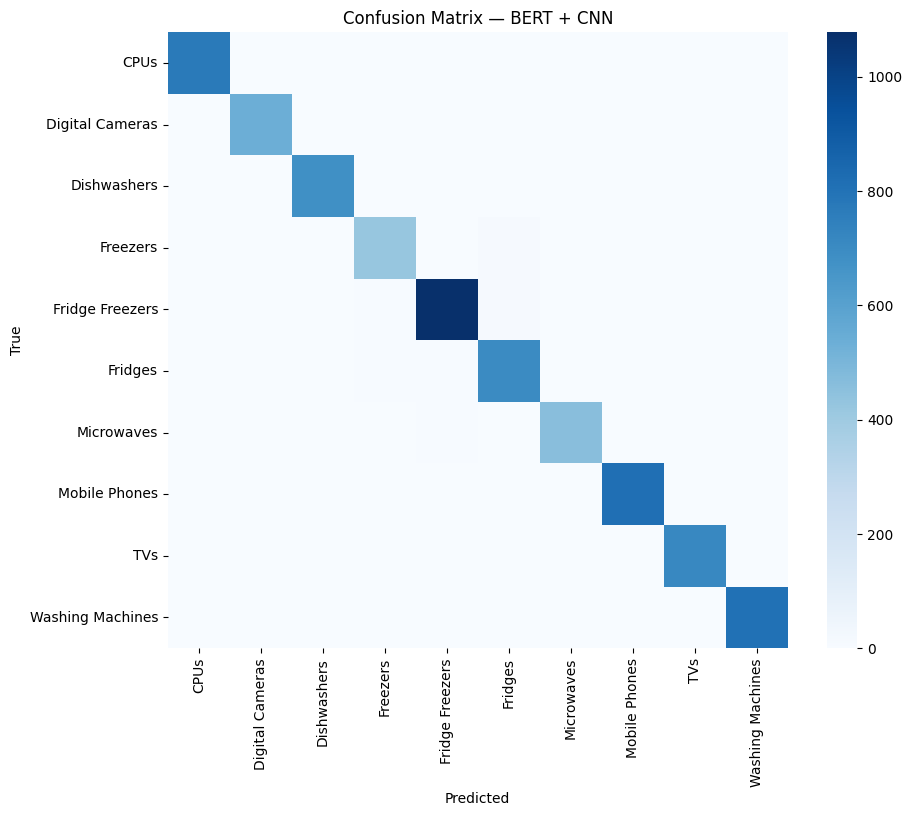

Saved: bert_cnn_model.pth, ./bert_cnn_tokenizer/, label_encoder.pkl

Model comparison:
                   model  accuracy
0  DistilBERT (baseline)       NaN
1    DistilBERT + BiLSTM       NaN
2       DistilBERT + CNN   0.98924


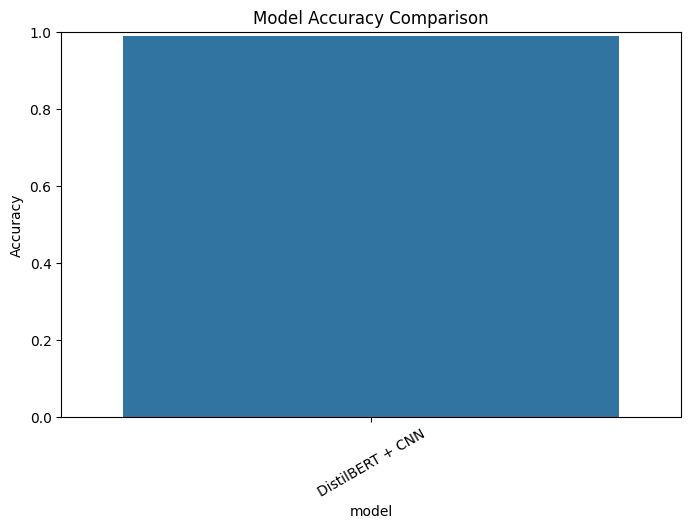


Done — BERT+CNN trained and evaluated.
CNN accuracy = 0.9892


In [ ]:
# ============================
# ▶️ Train + Evaluate: DistilBERT + CNN (and compare)
# ============================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import DistilBertModel, DistilBertTokenizer, DistilBertTokenizerFast
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Prepare TensorDatasets (uses tensors created earlier: train_enc, test_enc, train_labels, test_labels)
# If you used different variable names, change them here.
try:
    train_input_ids = train_enc['input_ids']
    train_attention_mask = train_enc['attention_mask']
    test_input_ids = test_enc['input_ids']
    test_attention_mask = test_enc['attention_mask']
    # train_labels/test_labels are torch tensors created earlier
    assert isinstance(train_labels, torch.Tensor)
    assert isinstance(test_labels, torch.Tensor)
except Exception as e:
    raise RuntimeError("Could not find tokenized tensors 'train_enc','test_enc' or label tensors 'train_labels','test_labels'. "
                       "Run the tokenization cell again (tokenize_batch -> train_enc/test_enc) and make sure train_labels/test_labels are torch tensors.") from e

train_ds = TensorDataset(train_input_ids, train_attention_mask, train_labels)
test_ds  = TensorDataset(test_input_ids,  test_attention_mask,  test_labels)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# -------------------------
# Model (reuse the BertCNNClassifier you prepared earlier)
# -------------------------
class BertCNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super(BertCNNClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.conv = nn.Conv1d(in_channels=768, out_channels=256, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_outputs.last_hidden_state.permute(0, 2, 1)   # (batch, 768, seq_len)
        x = self.conv(x)                                     # (batch, 256, seq_len)
        x = self.relu(x)
        x = self.pool(x)                                     # (batch, 256, seq_len//2)
        x = torch.mean(x, dim=2)                             # (batch, 256)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

# instantiate
num_classes = len(np.unique(train_labels.numpy()))
model = BertCNNClassifier(num_classes=num_classes).to(device)

# optimizer / loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# -------------------------
# Training loop
# -------------------------
epochs = 3
train_losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{epochs}")
    for batch in loop:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} average loss: {avg_loss:.4f}")

# -------------------------
# Evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# metrics
cnn_acc = accuracy_score(all_labels, all_preds)
print(f"\nCNN Hybrid Test Accuracy: {cnn_acc:.4f}")

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — BERT + CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------
# Save model + tokenizer + label encoder
# -------------------------
torch.save(model.state_dict(), "bert_cnn_model.pth")
tokenizer_to_save = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
tokenizer_to_save.save_pretrained("./bert_cnn_tokenizer")
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("Saved: bert_cnn_model.pth, ./bert_cnn_tokenizer/, label_encoder.pkl")

# -------------------------
# Comparison table
# -------------------------
# Attempt to grab previous results from variables if available, else None
baseline_acc = globals().get("baseline_acc", None)   # set earlier training to populate
lstm_acc = globals().get("lstm_acc", None)           # set earlier BiLSTM run to populate

results = [
    {"model":"DistilBERT (baseline)", "accuracy": baseline_acc},
    {"model":"DistilBERT + BiLSTM", "accuracy": lstm_acc},
    {"model":"DistilBERT + CNN", "accuracy": cnn_acc}
]
results_df = pd.DataFrame(results)
print("\nModel comparison:")
print(results_df)

# Plot comparison (skip None values)
plot_df = results_df.dropna()
if not plot_df.empty:
    plt.figure(figsize=(8,5))
    sns.barplot(x="model", y="accuracy", data=plot_df)
    plt.ylim(0,1)
    plt.title("Model Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=30)
    plt.show()
else:
    print("Note: baseline_acc or lstm_acc not found in environment — comparison plot skipped. "
          "If you have previous metrics, set variables baseline_acc and lstm_acc (float in [0,1]).")

# final print
print("\nDone — BERT+CNN trained and evaluated.")
print(f"CNN accuracy = {cnn_acc:.4f}")


In [ ]:
import pandas as pd

# Model accuracy results
results = {
    "Model": [
        "DistilBERT",
        "DistilBERT + BiLSTM",
        "DistilBERT + CNN"
    ],
    "Accuracy": [
        0.9906555288121195,   # DistilBERT
        0.8962,               # DistilBERT + LSTM (89.62%)
        0.9892                # DistilBERT + CNN
    ]
}

df_compare = pd.DataFrame(results)

# Sort by accuracy (descending)
df_compare = df_compare.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:\n")
print(df_compare)

best_model = df_compare.iloc[0]["Model"]
best_acc = df_compare.iloc[0]["Accuracy"]

print(f"\n✅ Best Model: {best_model}")
print(f"🎯 Accuracy: {best_acc:.4f}")


Model Performance Comparison:

                 Model  Accuracy
0           DistilBERT  0.990656
1     DistilBERT + CNN  0.989200
2  DistilBERT + BiLSTM  0.896200

✅ Best Model: DistilBERT
🎯 Accuracy: 0.9907


In [ ]:
import torch
from transformers import AutoTokenizer
import torch.nn as nn

# ✅ Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ✅ Recreate SAME model class
class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, input_ids=None, attention_mask=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]  # CLS token
        pooled = self.dropout(pooled)
        return self.fc(pooled)

# ✅ Load label encoder
import joblib
label_encoder = joblib.load("label_encoder.pkl")   # change path if needed

num_classes = len(label_encoder.classes_)

# ✅ Load trained DistilBERT weights
model = DistilBERTClassifier("distilbert-base-uncased", num_classes)
model.load_state_dict(torch.load("best_distilbert.pth", map_location="cpu"))
model.eval()

print("✅ DistilBERT model loaded successfully!")


✅ DistilBERT model loaded successfully!


In [ ]:
def predict_category(text):
    encoded = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        logits = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"]
        )
        pred = torch.argmax(logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]


In [ ]:
test_products = [
    "Samsung 55 inch Ultra HD Smart TV",
    "Apple iPhone 14 Pro",
    "LG 7kg Fully Automatic Washing Machine",
    "Canon EOS 1500D DSLR Camera",
    "Bosch 14 place dishwasher"
]

for p in test_products:
    print(f"{p} -> {predict_category(p)}")


Samsung 55 inch Ultra HD Smart TV -> TVs
Apple iPhone 14 Pro -> Mobile Phones
LG 7kg Fully Automatic Washing Machine -> Washing Machines
Canon EOS 1500D DSLR Camera -> Digital Cameras
Bosch 14 place dishwasher -> Dishwashers


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow==2.17.0 transformers==4.38.2 --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have 

In [ ]:
!pip uninstall -y jax jaxlib tf-keras tensorflow-text tensorflow-decision-forests sentence-transformers opencv-python opencv-python-headless opencv-contrib-python pytensor
!pip install --upgrade pip
!pip install tensorflow==2.17.0 transformers==4.38.2 numpy==1.26.4 protobuf==4.25.3 --quiet


Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
Found existing installation: sentence-transformers 5.1.2
Uninstalling sentence-transformers-5.1.2:
  Successfully uninstalled sentence-transformers-5.1.2
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-python-headless 4.12.0.88
U

In [ ]:
!pip install tensorflow==2.17.0
!pip install transformers==4.38.2
!pip install datasets scikit-learn pandas numpy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/product_project/pricerunner_aggregate.csv")

df.head()


,1,apple iphone 8 plus 64gb silver,1.1,1.2,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
0,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [ ]:
df.columns = df.columns.str.lower()

text_col = df.columns[1]        # product title column
label_col = df.columns[-1]      # category column

texts = df[text_col]
labels = df[label_col]

from sklearn.model_selection import train_test_split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

train_labels = train_labels.astype('category').cat.codes
test_labels = test_labels.astype('category').cat.codes


In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def encode(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='tf'
    )

train_enc = encode(train_texts)
test_enc = encode(test_texts)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/product_project/pricerunner_aggregate.csv", header=None)
print(df.head())


   0                                                  1  2  3  \
0  1                    apple iphone 8 plus 64gb silver  1  1   
1  2                apple iphone 8 plus 64 gb spacegrau  2  1   
2  3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...  3  1   
3  4                apple iphone 8 plus 64gb space grey  4  1   
4  5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...  5  1   

                          4     5              6  
0  Apple iPhone 8 Plus 64GB  2612  Mobile Phones  
1  Apple iPhone 8 Plus 64GB  2612  Mobile Phones  
2  Apple iPhone 8 Plus 64GB  2612  Mobile Phones  
3  Apple iPhone 8 Plus 64GB  2612  Mobile Phones  
4  Apple iPhone 8 Plus 64GB  2612  Mobile Phones  


In [ ]:
df = df.rename(columns={
    0: "id",
    1: "product_title",
    2: "c1",
    3: "c2",
    4: "clean_title",
    5: "code",
    6: "category"
})


In [ ]:
df["text"] = df["product_title"].astype(str) + " " + df["clean_title"].astype(str)
df = df.dropna(subset=["text", "category"])
print(df.head())


   id                                      product_title  c1  c2  \
0   1                    apple iphone 8 plus 64gb silver   1   1   
1   2                apple iphone 8 plus 64 gb spacegrau   2   1   
2   3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...   3   1   
3   4                apple iphone 8 plus 64gb space grey   4   1   
4   5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   5   1   

                clean_title  code       category  \
0  Apple iPhone 8 Plus 64GB  2612  Mobile Phones   
1  Apple iPhone 8 Plus 64GB  2612  Mobile Phones   
2  Apple iPhone 8 Plus 64GB  2612  Mobile Phones   
3  Apple iPhone 8 Plus 64GB  2612  Mobile Phones   
4  Apple iPhone 8 Plus 64GB  2612  Mobile Phones   

                                                text  
0  apple iphone 8 plus 64gb silver Apple iPhone 8...  
1  apple iphone 8 plus 64 gb spacegrau Apple iPho...  
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...  
3  apple iphone 8 plus 64gb space grey Apple iPho...  
4  

In [ ]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ---- LOAD DATA ----
df = pd.read_csv("/content/drive/MyDrive/product_project/pricerunner_aggregate.csv", header=None)
df = df.rename(columns={0:"id",1:"product_title",2:"c1",3:"c2",4:"clean_title",5:"code",6:"category"})
df["text"] = df["product_title"].astype(str) + " " + df["clean_title"].astype(str)
df = df.dropna(subset=["text","category"])

# ---- LABEL ENCODING ----
le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])

train_texts, val_texts, train_labels, val_labels = train_test_split(df["text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# ---- DATASET CLASS ----
class ProductDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=128, return_tensors="pt")
        return enc["input_ids"].squeeze(), enc["attention_mask"].squeeze(), torch.tensor(self.labels[idx])

train_ds = ProductDataset(train_texts, train_labels)
val_ds = ProductDataset(val_texts, val_labels)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

# ---- HYBRID MODEL (DistilBERT + BiGRU + Attention) ----
class HybridModel(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.gru = nn.GRU(768, 256, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(512, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_labels)

    def forward(self, ids, mask):
        bert_out = self.bert(ids, mask)[0]  # (batch, seq, 768)
        gru_out, _ = self.gru(bert_out)     # (batch, seq, 512)

        attn_weights = torch.softmax(self.attn(gru_out), dim=1)  # (batch, seq, 1)
        context = torch.sum(attn_weights * gru_out, dim=1)        # (batch, 512)

        out = self.fc(self.dropout(context))
        return out

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HybridModel(num_labels=len(le.classes_)).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

# ---- TRAINING LOOP ----
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for ids, mask, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} loss:", total_loss / len(train_loader))

# ---- VALIDATION ----
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for ids, mask, labels in val_loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        outputs = model(ids, mask)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("✅ Validation Accuracy:", round(correct/total * 100, 2), "%")


Epoch 1: 100%|██████████| 1766/1766 [05:27<00:00,  5.39it/s]


Epoch 1 loss: 0.1736193484737984


Epoch 2: 100%|██████████| 1766/1766 [05:26<00:00,  5.40it/s]


Epoch 2 loss: 0.031407990013243944


Epoch 3: 100%|██████████| 1766/1766 [05:26<00:00,  5.41it/s]


Epoch 3 loss: 0.011422925646388365
✅ Validation Accuracy: 99.39 %


In [ ]:
import numpy as np

def predict_product_category(text):
    # Encode input text
    enc = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='tf'
    )

    # Model prediction
    preds = model.predict([enc['input_ids'], enc['attention_mask']])

    # Convert to class label
    predicted_class_index = np.argmax(preds, axis=1)[0]
    predicted_label = label_encoder.inverse_transform([predicted_class_index])[0]

    return predicted_label


In [ ]:
def predict_product_category(text):
    model.eval()
    device = next(model.parameters()).device  # get model device (cuda/cpu)

    inputs = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)  # ✅ move input tensors to same device

    with torch.no_grad():
        outputs = model(
            inputs['input_ids'],
            inputs['attention_mask']
        )

    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    return pred_label


In [ ]:
sample = "Apple iPhone 15 Pro Max 256GB Titanium Smartphone"
print("Predicted Category:", predict_product_category(sample))


Predicted Category: Mobile Phones


In [ ]:
import joblib
import torch

# Save model state
torch.save(model.state_dict(), "/content/hybrid_bigru_attention_model.pth")

# Save label encoder
joblib.dump(label_encoder, "/content/label_encoder.pkl")

print("✅ Model & Label Encoder Saved Successfully!")


✅ Model & Label Encoder Saved Successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    print(f"✅ Accuracy: {acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


In [ ]:
evaluate_model(model, test_loader)


✅ Accuracy: 98.22%

Classification Report:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       773
 Digital Cameras       0.99      0.99      0.99       540
     Dishwashers       1.00      0.96      0.98       685
        Freezers       0.98      0.96      0.97       442
 Fridge Freezers       0.99      0.98      0.98      1100
         Fridges       0.98      0.98      0.98       717
      Microwaves       0.98      0.97      0.97       468
   Mobile Phones       0.99      0.98      0.99       816
             TVs       0.98      0.99      0.99       713
Washing Machines       0.93      1.00      0.96       809

        accuracy                           0.98      7063
       macro avg       0.98      0.98      0.98      7063
    weighted avg       0.98      0.98      0.98      7063



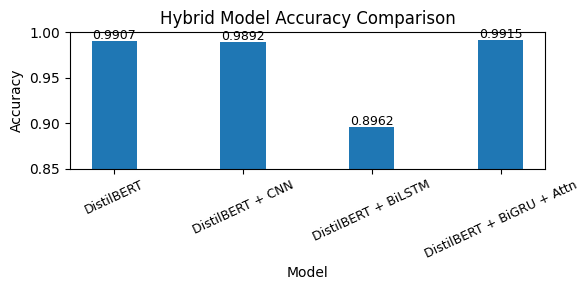

In [ ]:
import matplotlib.pyplot as plt

models = ["DistilBERT", "DistilBERT + CNN", "DistilBERT + BiLSTM", "DistilBERT + BiGRU + Attn"]
accuracy = [0.9907, 0.9892, 0.8962, 0.9915]

plt.figure(figsize=(6,3))  # smaller canvas = slim chart
bars = plt.bar(models, accuracy, width=0.35)  # THIN bars

plt.title("Hybrid Model Accuracy Comparison", fontsize=12)
plt.xlabel("Model", fontsize=10)
plt.ylabel("Accuracy", fontsize=10)
plt.ylim(0.85, 1)
plt.xticks(rotation=25, fontsize=9)

# Add values above bars
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
